In [1]:
#PHASE 2 
import pandas as pd
df= pd.read_csv('D:/credit_risk/data/processed/cleaned_data.csv')
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [2]:
#X=features, y=target variable
X=df.drop('default', axis=1)
y=df['default']

In [3]:
# MODEL BULDING AND EVALUATION
from sklearn.model_selection import train_test_split #for training and testing the model
from sklearn.ensemble import RandomForestClassifier #for building the model
from sklearn.metrics import accuracy_score, classification_report # to get the accuracy of the model

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model=RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)

#predictions
y_pred=model.predict(X_test)

print("Accuracy Score::")
print( accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))




Accuracy Score::
0.8167120799273387

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4279
           1       0.66      0.37      0.47      1226

    accuracy                           0.82      5505
   macro avg       0.75      0.66      0.68      5505
weighted avg       0.80      0.82      0.80      5505



In [4]:
#handling imbalanced data with class_weight='balanced'

model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4279
           1       0.67      0.34      0.45      1226

    accuracy                           0.82      5505
   macro avg       0.75      0.64      0.67      5505
weighted avg       0.80      0.82      0.79      5505



Confusion Matrix:
 [[4076  203]
 [ 815  411]]


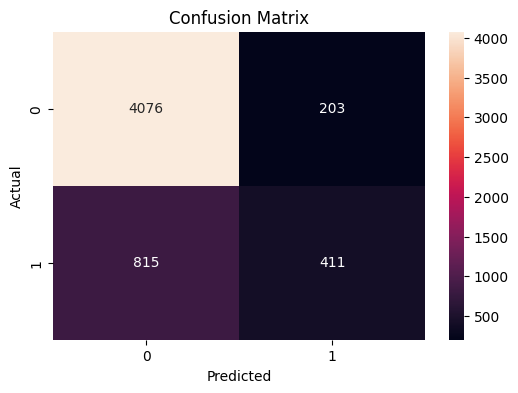

In [5]:
#CONFUSION MATRIX       
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Print values
print("Confusion Matrix:\n", cm)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [6]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

PAY_0        0.099058
LIMIT_BAL    0.065572
BILL_AMT1    0.062361
AGE          0.061863
BILL_AMT2    0.053651
PAY_AMT1     0.052286
PAY_AMT2     0.050228
BILL_AMT3    0.050207
BILL_AMT4    0.049442
BILL_AMT6    0.049004
dtype: float64

In [7]:
#changing the threshhold 0.3 instead of 0.5
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_threshold = (y_pred_proba >= 0.3).astype(int)

In [8]:
print(classification_report(y_test, y_pred_threshold ))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86      4279
           1       0.52      0.54      0.53      1226

    accuracy                           0.79      5505
   macro avg       0.69      0.70      0.70      5505
weighted avg       0.79      0.79      0.79      5505

